# Chord Classification Error Analysis

**Goal**: Understand why `broken_sustain` and `normal_no-sustain` have much lower classification accuracy than `normal_sustain` when using ground-truth annotations for segmentation (i.e., the errors are *purely from the classifier*, not onset detection).

From prior runs we observe a dramatic **bias towards predicting `C:dim`** on the "bad" datasets:
- In `normal_no-sustain`, ~30% of all segments that are *not* C:dim are classified as C:dim (often with very high confidence).
- `broken_sustain` shows similar but milder bias.
- `normal_sustain` has almost none of this.

**Questions we investigate**:
- What acoustic / spectral differences exist in the CQT windows fed to the model across the three validation construction styles?
- Is the bias caused by "lack of sustain" (fast decay envelopes), transients, weaker harmonics, or other artifacts introduced when the source chord samples were recorded/processed without long sustains or with "broken" sustains?
- Visual + quantitative comparison of CQT features for misclassified segments (especially those confidently called C:dim) vs. correctly classified equivalents (including true C:dim from the "good" dataset).

The CQT parameters, windowing (start at annotated chord onset, length capped before next onset or 2 s, then stretched to 188 frames), and model are identical to the rest of the research / `onset-classify_annotation.ipynb`.


In [1]:
import gc
from os import path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import mir_eval
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import classification_report

FEATURES_PATH = path.normpath("../../validations/")
MODEL_SAVE_PATH = path.normpath("../../models/model-bn-c64-c128-c256-c256-d256.keras")

AUDIO_MIN_DURATION = 2  # seconds
AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36
CQT_FEATURE_FRAMES = round(AUDIO_MIN_DURATION * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)
CQT_FMIN = librosa.note_to_hz("C1")

print("CQT_FEATURE_FRAMES (model input time dim):", CQT_FEATURE_FRAMES)
# sns.set_style("whitegrid")
# plt.rcParams["figure.dpi"] = 110


2026-06-05 13:50:14.975243: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-05 13:50:14.975287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-05 13:50:14.991662: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-05 13:50:15.021653: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-05 13:50:16.124911: W tensorflow/compiler/tf2

CQT_FEATURE_FRAMES (model input time dim): 188


In [2]:
model = tf.keras.models.load_model(MODEL_SAVE_PATH, compile=False)
print("Model loaded. Output shape:", model.output_shape)

MODEL_LABELS = [
    'A#_diminished_4', 'A#_major_4', 'A#_minor_4',
    'A_diminished_4', 'A_major_4', 'A_minor_4',
    'B_diminished_4', 'B_major_4', 'B_minor_4',
    'C#_diminished_4', 'C#_major_4', 'C#_minor_4',
    'C_diminished_4', 'C_major_4', 'C_minor_4',
    'D#_diminished_4', 'D#_major_4', 'D#_minor_4',
    'D_diminished_4', 'D_major_4', 'D_minor_4',
    'E_diminished_4', 'E_major_4', 'E_minor_4',
    'F#_diminished_4', 'F#_major_4', 'F#_minor_4',
    'F_diminished_4', 'F_major_4', 'F_minor_4',
    'G#_diminished_4', 'G#_major_4', 'G#_minor_4',
    'G_diminished_4', 'G_major_4', 'G_minor_4',
]

if model.output_shape[-1] != len(MODEL_LABELS):
    raise ValueError("Model output size mismatch")

VALIDATION_DATASETS = ["normal_sustain", "broken_sustain", "normal_no-sustain"]
print("Datasets to analyze:", VALIDATION_DATASETS)


2026-06-05 13:50:17.996082: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-05 13:50:18.159303: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-05 13:50:18.161708: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model loaded. Output shape: (None, 36)
Datasets to analyze: ['normal_sustain', 'broken_sustain', 'normal_no-sustain']


# Core helpers (normalization, stretching, window extraction, classification)

These are the same as used in `onset-classify_annotation.ipynb` so that the windows the model sees are *identical*.


In [3]:
MIR_EVAL_QUALITY_MAP = {
    "major": "maj", "maj": "maj", "minor": "min", "min": "min",
    "diminished": "dim", "dim": "dim", "augmented": "aug", "aug": "aug",
    "N": mir_eval.chord.NO_CHORD, "n": mir_eval.chord.NO_CHORD,
    "no_chord": mir_eval.chord.NO_CHORD, "no-chord": mir_eval.chord.NO_CHORD,
}

def normalize_chord_label(chord_label):
    if chord_label is None:
        return mir_eval.chord.NO_CHORD
    chord_label = str(chord_label).strip()
    if chord_label in {mir_eval.chord.NO_CHORD, "N", "n"}:
        return mir_eval.chord.NO_CHORD
    if ":" in chord_label and "_" not in chord_label:
        root, quality = chord_label.split(":", 1)
        normalized_quality = MIR_EVAL_QUALITY_MAP.get(quality.lower(), quality.lower())
        if normalized_quality == mir_eval.chord.NO_CHORD:
            return mir_eval.chord.NO_CHORD
        return f"{root}:{normalized_quality}"
    parts = chord_label.split("_")
    if len(parts) >= 2:
        root = parts[0]
        quality = "_".join(parts[1:-1]) if len(parts) > 2 else parts[1]
        normalized_quality = MIR_EVAL_QUALITY_MAP.get(quality.lower(), quality.lower())
        if normalized_quality == mir_eval.chord.NO_CHORD:
            return mir_eval.chord.NO_CHORD
        return f"{root}:{normalized_quality}"
    return chord_label

def annotation_to_interval_and_label(annotation):
    if isinstance(annotation, dict):
        start_time = float(annotation["start"])
        end_time = float(annotation["end"])
        chord_label = annotation.get("chord", annotation.get("label", mir_eval.chord.NO_CHORD))
    elif isinstance(annotation, (list, tuple)) and len(annotation) >= 3:
        start_time, end_time, chord_label = annotation[:3]
    else:
        raise TypeError(f"Unsupported annotation format: {type(annotation)!r}")
    return (float(start_time), float(end_time)), normalize_chord_label(chord_label)

def annotations_to_mir_eval(annotations):
    intervals, labels = [], []
    for annotation in annotations:
        interval, label = annotation_to_interval_and_label(annotation)
        intervals.append(interval)
        labels.append(label)
    intervals = np.asarray(intervals, dtype=float)
    if intervals.size == 0:
        return intervals.reshape(0, 2), labels
    order = np.argsort(intervals[:, 0], kind="mergesort")
    intervals = intervals[order]
    labels = [labels[i] for i in order]
    merged_intervals = [intervals[0].tolist()]
    merged_labels = [labels[0]]
    for interval, label in zip(intervals[1:], labels[1:]):
        if label == merged_labels[-1] and np.isclose(interval[0], merged_intervals[-1][1]):
            merged_intervals[-1][1] = float(interval[1])
        else:
            merged_intervals.append(interval.tolist())
            merged_labels.append(label)
    return np.asarray(merged_intervals, dtype=float), merged_labels

def stretch_features_to_frames(feature_array, target_frames=CQT_FEATURE_FRAMES):
    feature_array = np.asarray(feature_array)
    if feature_array.ndim == 2:
        source_frames = feature_array.shape[1]
        if source_frames == target_frames:
            return feature_array.astype(np.float32, copy=False)
        if source_frames == 1:
            return np.repeat(feature_array, target_frames, axis=1).astype(np.float32, copy=False)
        source_positions = np.linspace(0.0, 1.0, source_frames)
        target_positions = np.linspace(0.0, 1.0, target_frames)
        stretched_rows = [np.interp(target_positions, source_positions, row) for row in feature_array]
        return np.asarray(stretched_rows, dtype=np.float32)
    if feature_array.ndim == 3:
        return np.stack([stretch_features_to_frames(sample, target_frames) for sample in feature_array], axis=0)
    raise ValueError(f"Expected 2D or 3D, got {feature_array.shape}")

def classify_chord_window(window_cqt):
    window_input = window_cqt[np.newaxis, ..., np.newaxis].astype(np.float32, copy=False)
    predictions = model.predict(window_input, verbose=0)[0]
    idx = int(np.argmax(predictions))
    return MODEL_LABELS[idx], idx, predictions

def build_estimated_annotations_for_sample(sample_cqt, reference_annotations, dataset_name, sample_index):
    """Return per-segment predictions + intervals using ground-truth annotation boundaries (exact same logic as the annotation notebook)."""
    sample_frames = int(sample_cqt.shape[1])
    sample_duration = float(librosa.frames_to_time(sample_frames, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH))
    estimated_intervals, estimated_labels, prediction_rows = [], [], []
    ann_list = []
    for ann in (reference_annotations or []):
        if isinstance(ann, dict):
            st, en, lab = float(ann.get("start", 0.0)), float(ann.get("end", 0.0)), ann.get("chord", ann.get("label", None))
        elif isinstance(ann, (list, tuple)) and len(ann) >= 2:
            st, en, lab = float(ann[0]), float(ann[1]), (ann[2] if len(ann) >= 3 else None)
        else:
            continue
        ann_list.append((st, en, lab))
    ann_list.sort(key=lambda x: x[0])
    num_anns = len(ann_list)
    if num_anns == 0:
        window_end_frame = min(sample_frames, CQT_FEATURE_FRAMES)
        window_cqt = sample_cqt[:, :window_end_frame] if window_end_frame > 0 else sample_cqt[:, :1]
        if window_cqt.shape[1] == 0 and sample_frames > 0:
            window_cqt = sample_cqt[:, :1]
        stretched = stretch_features_to_frames(window_cqt, CQT_FEATURE_FRAMES)
        raw_label, pidx, probs = classify_chord_window(stretched)
        estimated_intervals.append([0.0, sample_duration])
        estimated_labels.append(mir_eval.chord.NO_CHORD)
        prediction_rows.append({
            "dataset": dataset_name, "sample_index": sample_index, "segment_index": 0,
            "onset_time": 0.0, "window_frames": int(window_cqt.shape[1]),
            "raw_prediction": raw_label, "prediction": mir_eval.chord.NO_CHORD,
            "prediction_index": pidx, "confidence": float(probs[pidx]),
        })
    else:
        for seg_idx, (st, en, _lab) in enumerate(ann_list):
            start_frame = int(librosa.time_to_frames(st, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH))
            if seg_idx + 1 < num_anns:
                next_st = ann_list[seg_idx + 1][0]
                next_frame = int(librosa.time_to_frames(next_st, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH))
            else:
                next_frame = sample_frames
            w_start = max(0, start_frame)
            w_end = min(w_start + CQT_FEATURE_FRAMES, next_frame, sample_frames)
            if w_end <= w_start:
                if w_start >= sample_frames: continue
                w_cqt = sample_cqt[:, w_start:w_start + 1]
            else:
                w_cqt = sample_cqt[:, w_start:w_end]
            stretched = stretch_features_to_frames(w_cqt, CQT_FEATURE_FRAMES)
            raw_label, pidx, probs = classify_chord_window(stretched)
            pred_label = normalize_chord_label(raw_label)
            estimated_intervals.append([st, en])
            estimated_labels.append(pred_label)
            prediction_rows.append({
                "dataset": dataset_name, "sample_index": sample_index, "segment_index": seg_idx,
                "onset_time": st, "window_frames": int(w_cqt.shape[1]),
                "raw_prediction": raw_label, "prediction": pred_label,
                "prediction_index": pidx, "confidence": float(probs[pidx]),
            })
    return {
        "estimated_intervals": np.asarray(estimated_intervals, dtype=float) if estimated_intervals else np.zeros((0,2), dtype=float),
        "estimated_labels": estimated_labels,
        "predictions": pd.DataFrame(prediction_rows),
        "num_segments": len(estimated_labels),
    }

def extract_window_for_segment(sample_cqt, reference_annotations, seg_index):
    """Replicate the exact window slicing logic used for classification. Returns the raw (variable-length) CQT slice the model saw for that annotated segment (before stretching)."""
    ann_list = []
    for ann in (reference_annotations or []):
        if isinstance(ann, dict):
            st, en = float(ann.get("start", 0.0)), float(ann.get("end", 0.0))
        elif isinstance(ann, (list, tuple)) and len(ann) >= 2:
            st, en = float(ann[0]), float(ann[1])
        else:
            continue
        ann_list.append((st, en))
    ann_list.sort(key=lambda x: x[0])
    if seg_index < 0 or seg_index >= len(ann_list):
        raise IndexError("seg_index out of range")
    start_time, end_time = ann_list[seg_index]
    start_frame = int(librosa.time_to_frames(start_time, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH))
    if seg_index + 1 < len(ann_list):
        next_start = ann_list[seg_index + 1][0]
        next_frame = int(librosa.time_to_frames(next_start, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH))
    else:
        next_frame = sample_cqt.shape[1]
    w_start = max(0, start_frame)
    w_end = min(w_start + CQT_FEATURE_FRAMES, next_frame, sample_cqt.shape[1])
    if w_end <= w_start:
        w_end = min(w_start + 1, sample_cqt.shape[1])
    window_cqt = sample_cqt[:, w_start:w_end].copy()
    return window_cqt, w_start, w_end, start_time, end_time

print("Helpers loaded.")


Helpers loaded.


# Collect per-segment predictions + lightweight acoustic features

We run the ground-truth-annotation segmentation + classification exactly as in the previous notebook, but also compute simple per-window features that may explain the failures:
- `sustain_ratio`: (energy in last 1/3 of the window) / (energy in first 1/3). Low values → fast decay / little sustain.
- `attack_pos`: position of peak frame energy (normalized 0-1). Useful to see if attacks are early/late.
- Plus basic duration / window length info.

These are computed on the *exact* (pre-stretch) window that is later stretched and fed to the CNN.


In [4]:
def compute_window_stats(window_cqt):
    if window_cqt.size == 0:
        return {"sustain_ratio": 0.0, "attack_pos": 0.5, "total_energy": 0.0, "window_frames": 0}
    energy = window_cqt.sum(axis=0).astype(float)
    n = len(energy)
    if n < 3:
        return {"sustain_ratio": 1.0, "attack_pos": 0.0, "total_energy": float(energy.sum()), "window_frames": n}
    third = max(1, n // 3)
    head = energy[:third].sum() + 1e-9
    tail = energy[-third:].sum()
    sustain_ratio = float(tail / head)
    attack_pos = float(np.argmax(energy) / n)

    # NEW: Frequency-domain noise metrics
    bin_energy = window_cqt.sum(axis=1).astype(float)  # energy per frequency bin
    
    # Spectral spread (std) - lower = more focused/tonal
    spectral_std = float(np.std(bin_energy))
    
    # Spectral flatness (geometric mean / arithmetic mean)
    # Higher = more noise-like, Lower = more tonal
    bin_safe = np.maximum(bin_energy, 1e-10)
    spectral_flatness = np.exp(np.mean(np.log(bin_safe))) / (np.mean(bin_safe) + 1e-10)
    
    return {
        "sustain_ratio": sustain_ratio,
        "attack_pos": attack_pos,
        "total_energy": float(energy.sum()),
        "window_frames": n,
        "spectral_std": spectral_std,
        "spectral_flatness": spectral_flatness,
    }

def build_segments_dataframe(dataset_names):
    """Run classification with oracle segments on the requested datasets.
    Returns a rich dataframe (one row per annotated chord segment) with predictions, correctness,
    timing, and the acoustic stats above. Also returns a dict of the raw npz data for on-demand window extraction.
    """
    raw_data = {}
    all_rows = []
    for ds in dataset_names:
        npz = np.load(path.join(FEATURES_PATH, f"{ds}.npz"), allow_pickle=True)
        feats = npz["features"]
        anns = npz["annotations"]
        raw_data[ds] = {"features": feats, "annotations": anns}
        n_samples = len(feats)
        for sidx in range(n_samples):
            sample_cqt = feats[sidx]
            sample_anns = anns[sidx]
            pred_result = build_estimated_annotations_for_sample(sample_cqt, sample_anns, ds, sidx)
            pred_df = pred_result["predictions"]
            for _, prow in pred_df.iterrows():
                segi = int(prow.segment_index)
                # true label from annotation
                ann = sample_anns[segi]
                true_raw = ann.get("chord", ann.get("label")) if isinstance(ann, dict) else (ann[2] if len(ann) > 2 else None)
                true = normalize_chord_label(true_raw)
                pred = prow["prediction"]
                # re-extract the precise window to get acoustic stats (very cheap)
                w_cqt, _, _, st_t, en_t = extract_window_for_segment(sample_cqt, sample_anns, segi)
                stats = compute_window_stats(w_cqt)
                dur = en_t - st_t
                row = {
                    "dataset": ds,
                    "sample_index": sidx,
                    "segment_index": segi,
                    "true": true,
                    "pred": pred,
                    "correct": (pred == true),
                    "confidence": float(prow["confidence"]),
                    "start_time": st_t,
                    "end_time": en_t,
                    "duration": dur,
                    "window_frames": stats["window_frames"],
                    "sustain_ratio": stats["sustain_ratio"],
                    "attack_pos": stats["attack_pos"],
                    "total_energy": stats["total_energy"],
                    "spectral_std": stats["spectral_std"],
                    "spectral_flatness": stats["spectral_flatness"],
                }
                all_rows.append(row)
        print(f"Collected {len([r for r in all_rows if r['dataset']==ds])} segments for {ds}")
    seg_df = pd.DataFrame(all_rows)
    seg_df["error"] = ~seg_df["correct"]
    return seg_df, raw_data

print("Building segments dataframe (this runs the model forward passes)...")
segments_df, raw_data = build_segments_dataframe(VALIDATION_DATASETS)
errors_df = segments_df[segments_df.error].copy()
print(f"Total segments: {len(segments_df)}, total errors: {len(errors_df)}")
display(segments_df.groupby("dataset").agg(
    n_segments=("true", "count"),
    n_errors=("error", "sum"),
    seg_error_rate=("error", "mean"),
    mean_confidence=("confidence", "mean"),
    mean_sustain_ratio=("sustain_ratio", "mean"),
).round(3))


Building segments dataframe (this runs the model forward passes)...


2026-06-05 13:50:21.789671: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-06-05 13:50:21.966710: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-05 13:50:22.530906: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Collected 100 segments for normal_sustain
Collected 200 segments for broken_sustain
Collected 320 segments for normal_no-sustain
Total segments: 620, total errors: 185


,n_segments,n_errors,seg_error_rate,mean_confidence,mean_sustain_ratio
dataset,,,,,
broken_sustain,200,59,0.295,0.790,0.169
normal_no-sustain,320,119,0.372,0.715,0.141
normal_sustain,100,7,0.070,0.905,0.214


In [5]:
print("=== Prediction distribution on *errors* (the bias) ===")
for ds in VALIDATION_DATASETS:
    e = errors_df[errors_df.dataset == ds]
    print(f"\n{ds} ({len(e)} errors):")
    print(e["pred"].value_counts().head(5))

print("\n=== % of non-C:dim segments predicted as C:dim (strong bias indicator) ===")
for ds in VALIDATION_DATASETS:
    g = segments_df[segments_df.dataset == ds]
    non_cdim = g[g.true != "C:dim"]
    wrong_cdim = ((non_cdim.pred == "C:dim")).sum()
    rate = wrong_cdim / len(non_cdim) if len(non_cdim) > 0 else 0
    print(f"{ds}: {wrong_cdim}/{len(non_cdim)} = {rate:.1%}")

print("\n=== Top (true -> C:dim) confusions (counts) in the bad datasets ===")
cdim_wrongs = errors_df[(errors_df.pred == "C:dim") & (errors_df.dataset.isin(["broken_sustain", "normal_no-sustain"]))]
pairs = cdim_wrongs.groupby(["dataset", "true"]).size().reset_index(name="count").sort_values(["dataset", "count"], ascending=[True, False])
print(pairs.head(15).to_string())

print("\n=== Per-true-chord error rate (bad datasets only, top problematic chords) ===")
bad = segments_df[segments_df.dataset.isin(["broken_sustain", "normal_no-sustain"])]
per_true = bad.groupby(["dataset", "true"]).apply(
    lambda g: pd.Series({
        "n": len(g),
        "errors": g.error.sum(),
        "error_rate": g.error.mean(),
        "mean_conf_on_error": g[g.error].confidence.mean() if g.error.any() else np.nan,
    })
).reset_index()
print(per_true.sort_values(["dataset", "error_rate"], ascending=[True, False]).head(12).round(3).to_string())


=== Prediction distribution on *errors* (the bias) ===

normal_sustain (7 errors):
pred
C#:dim    3
D#:min    1
E:dim     1
F#:maj    1
B:min     1
Name: count, dtype: int64

broken_sustain (59 errors):
pred
C:dim     29
C#:dim    11
E:dim      6
D#:dim     5
D#:min     2
Name: count, dtype: int64

normal_no-sustain (119 errors):
pred
C:dim     97
C#:dim    11
E:dim      3
C:min      2
G:maj      2
Name: count, dtype: int64

=== % of non-C:dim segments predicted as C:dim (strong bias indicator) ===
normal_sustain: 0/94 = 0.0%
broken_sustain: 29/192 = 15.1%
normal_no-sustain: 97/310 = 31.3%

=== Top (true -> C:dim) confusions (counts) in the bad datasets ===
              dataset    true  count
9      broken_sustain   D:maj      7
1      broken_sustain  A#:min      5
10     broken_sustain  F#:dim      3
0      broken_sustain  A#:maj      2
6      broken_sustain  D#:dim      2
12     broken_sustain  G#:maj      2
2      broken_sustain   A:dim      1
3      broken_sustain   B:dim      1
4

/tmp/ipykernel_1272626/559444137.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_true = bad.groupby(["dataset", "true"]).apply(


# Acoustic / temporal feature differences across datasets and correctness

If "no sustain" or "broken sustain" are the culprits, we expect systematic differences in `sustain_ratio` (and to a lesser extent `attack_pos`) between:
- normal_sustain vs the other two, and
- within a bad dataset: correct vs erroneous segments.

`sustain_ratio > 1` means the tail of the (pre-stretch) window still has comparable or more energy than the head — typical of a held/sustained chord. Low values (<0.3-0.5) mean strong attack + rapid decay into near-silence within the annotated segment.


=== sustain_ratio statistics (by dataset x correctness) ===
                            mean  median    std  count
dataset           correct                             
broken_sustain    False    0.183   0.177  0.063     59
                  True     0.163   0.157  0.057    141
normal_no-sustain False    0.149   0.145  0.033    119
                  True     0.137   0.130  0.042    201
normal_sustain    False    0.252   0.258  0.041      7
                  True     0.211   0.200  0.059     93

=== window_frames (pre-stretch length) stats ===
                            mean  median  min  max
dataset           correct                         
broken_sustain    False    169.1   187.0  107  188
                  True     168.6   188.0   73  188
normal_no-sustain False    172.3   188.0  100  188
                  True     156.6   166.0   59  188
normal_sustain    False    110.7   107.0   71  142
                  True     110.9   112.0   51  145


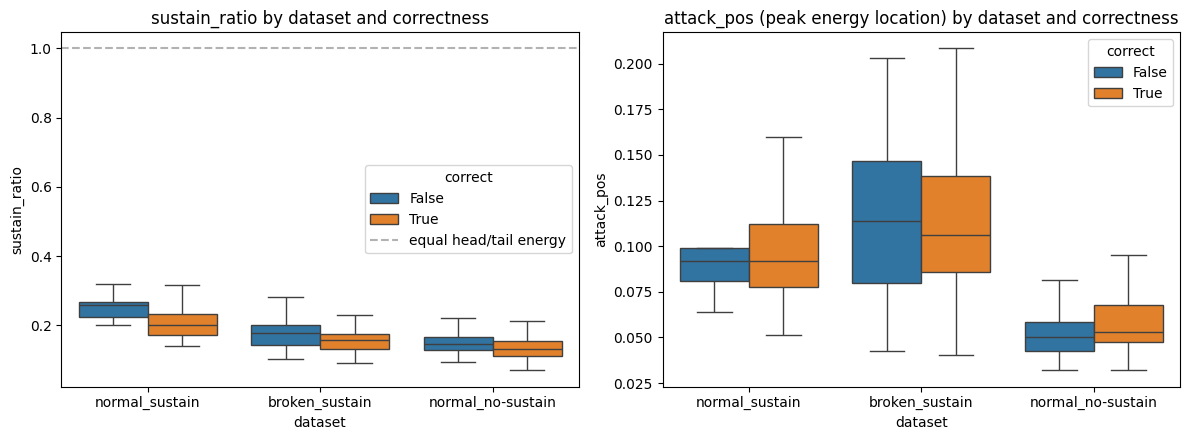

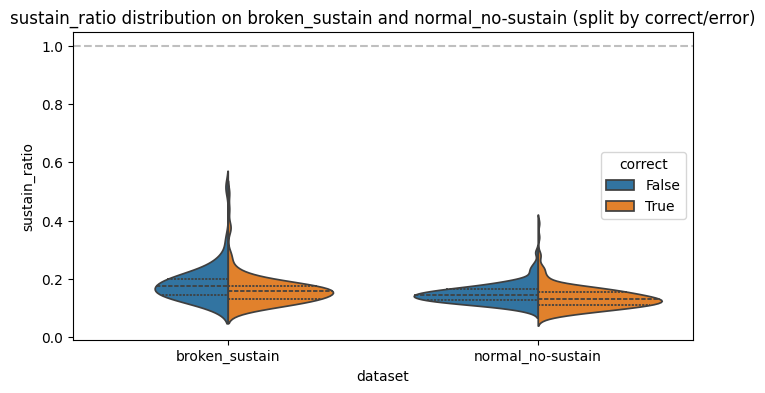

broken_sustain: error_rate when sustain_ratio < 0.6: 29.5% (n=200)
       error_rate when sustain_ratio >= 0.6: nan% (n=0)
normal_no-sustain: error_rate when sustain_ratio < 0.6: 37.2% (n=320)
       error_rate when sustain_ratio >= 0.6: nan% (n=0)


In [6]:
print("=== sustain_ratio statistics (by dataset x correctness) ===")
print(segments_df.groupby(["dataset", "correct"]).sustain_ratio.agg(["mean", "median", "std", "count"]).round(3))

print("\n=== window_frames (pre-stretch length) stats ===")
print(segments_df.groupby(["dataset", "correct"]).window_frames.agg(["mean", "median", "min", "max"]).round(1))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=segments_df, x="dataset", y="sustain_ratio", hue="correct", ax=axes[0], showfliers=False)
axes[0].set_title("sustain_ratio by dataset and correctness")
axes[0].axhline(1.0, color="gray", linestyle="--", alpha=0.6, label="equal head/tail energy")
axes[0].legend(title="correct")

sns.boxplot(data=segments_df, x="dataset", y="attack_pos", hue="correct", ax=axes[1], showfliers=False)
axes[1].set_title("attack_pos (peak energy location) by dataset and correctness")
axes[1].legend(title="correct")
plt.tight_layout()
plt.show()

# Focus on the bad datasets
fig, ax = plt.subplots(figsize=(8, 4))
bad_df = segments_df[segments_df.dataset.isin(["broken_sustain", "normal_no-sustain"])]
sns.violinplot(data=bad_df, x="dataset", y="sustain_ratio", hue="correct", split=True, inner="quartile", ax=ax)
ax.set_title("sustain_ratio distribution on broken_sustain and normal_no-sustain (split by correct/error)")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
plt.show()

# Quick correlation: does low sustain_ratio predict error in the bad sets?
for ds in ["broken_sustain", "normal_no-sustain"]:
    g = segments_df[segments_df.dataset == ds]
    thresh = 0.6
    low_sus = g[g.sustain_ratio < thresh]
    hi_sus = g[g.sustain_ratio >= thresh]
    print(f"{ds}: error_rate when sustain_ratio < {thresh}: {low_sus.error.mean():.1%} (n={len(low_sus)})")
    print(f"       error_rate when sustain_ratio >= {thresh}: {hi_sus.error.mean():.1%} (n={len(hi_sus)})")


# CQT Feature Case Studies

Here we visualize the actual (pre-stretch) CQT windows that were fed to the model for several high-confidence errors that collapsed to `C:dim`, plus reference correct examples (including true `C:dim` segments from `normal_sustain`).

For each case we show:
1. The raw variable-length CQT slice (as extracted from the annotated start, capped before the next chord).
2. The same slice after the time-stretch to exactly `CQT_FEATURE_FRAMES` (what the CNN actually received).
3. A reference window (often a correctly classified `C:dim` or a correct classification of the same true chord from a "good" context) for visual comparison.

Look for:
- Very short active regions followed by long low-energy tails (after stretch these become long "silence" or weak harmonic bands).
- Weaker or smeared harmonic stacks compared to the sustained reference.
- Overall "noisier" or less stable vertical structure across time.


In [7]:
def cqt_to_db(cqt):
    return librosa.power_to_db(np.maximum(cqt, 1e-10), ref=np.max)

def plot_cqt_window(window_cqt, title, ax=None, show_colorbar=True, stretched=False):
    if stretched:
        window_cqt = stretch_features_to_frames(window_cqt, CQT_FEATURE_FRAMES)
    # window_cqt = cqt_to_db(window_cqt)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure
    img = librosa.display.specshow(
        window_cqt,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        x_axis="time",
        y_axis="cqt_note",
        fmin=CQT_FMIN,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
        ax=ax,
        cmap="magma",
    )
    ax.set_title(title, fontsize=10)
    if show_colorbar:
        plt.colorbar(img, ax=ax, format="%+2.0f dB")
    return fig, ax

def plot_case_study(case, raw_data):
    """case = dict(ds, sample_index, segment_index, note)"""
    ds = case["ds"]
    sidx = case["sample_index"]
    segi = case["segment_index"]
    sample_cqt = raw_data[ds]["features"][sidx]
    anns = raw_data[ds]["annotations"][sidx]
    w_cqt, w0, w1, st, en = extract_window_for_segment(sample_cqt, anns, segi)
    ann = anns[segi]
    true = normalize_chord_label(ann.get("chord", ann.get("label")) if isinstance(ann, dict) else ann[2])
    # get the stored pred/conf from segments_df
    row = segments_df[(segments_df.dataset == ds) & (segments_df.sample_index == sidx) & (segments_df.segment_index == segi)].iloc[0]
    pred = row["pred"]
    conf = row["confidence"]
    sus = row["sustain_ratio"]
    title = f"{ds} s{sidx}/seg{segi}  true={true}  pred={pred} (conf={conf:.2f})  sustain_ratio={sus:.2f}\n{case.get('note','')}"
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    plot_cqt_window(w_cqt, title + " (raw window)", ax=axes[0], stretched=False)
    plot_cqt_window(w_cqt, "stretched to model input (188 frames)", ax=axes[1], stretched=True)
    plt.tight_layout()
    plt.show()
    return w_cqt

# Concrete interesting cases (high-confidence C:dim errors + references)
CASES = [
    # broken_sustain high-conf errors to C:dim
    {"ds": "broken_sustain", "sample_index": 0, "segment_index": 4, "note": "D:dim -> C:dim (very high conf)"},
    {"ds": "broken_sustain", "sample_index": 10, "segment_index": 7, "note": "D:maj -> C:dim"},
    # normal_no-sustain high-conf errors to C:dim
    {"ds": "normal_no-sustain", "sample_index": 28, "segment_index": 2, "note": "F#:min -> C:dim (extremely high conf ~0.994)"},
    {"ds": "normal_no-sustain", "sample_index": 26, "segment_index": 7, "note": "D:maj -> C:dim (~0.984)"},
    {"ds": "normal_no-sustain", "sample_index": 10, "segment_index": 5, "note": "D:maj -> C:dim"},
    # reference: correct C:dim from the good dataset
    {"ds": "normal_sustain", "sample_index": 0, "segment_index": 6, "note": "CORRECT C:dim reference (normal_sustain)"},
    # a correct classification inside a bad dataset for contrast
    {"ds": "normal_no-sustain", "sample_index": 0, "segment_index": 3, "note": "CORRECT C:min inside normal_no-sustain"},
]

print("Case studies prepared. Will plot on next cell execution.")


Case studies prepared. Will plot on next cell execution.


Generating case study CQT plots (raw + stretched views)...


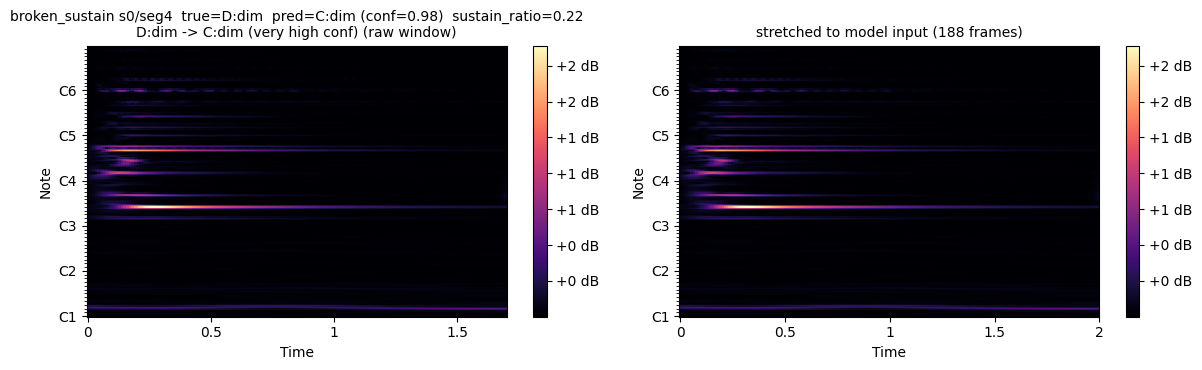

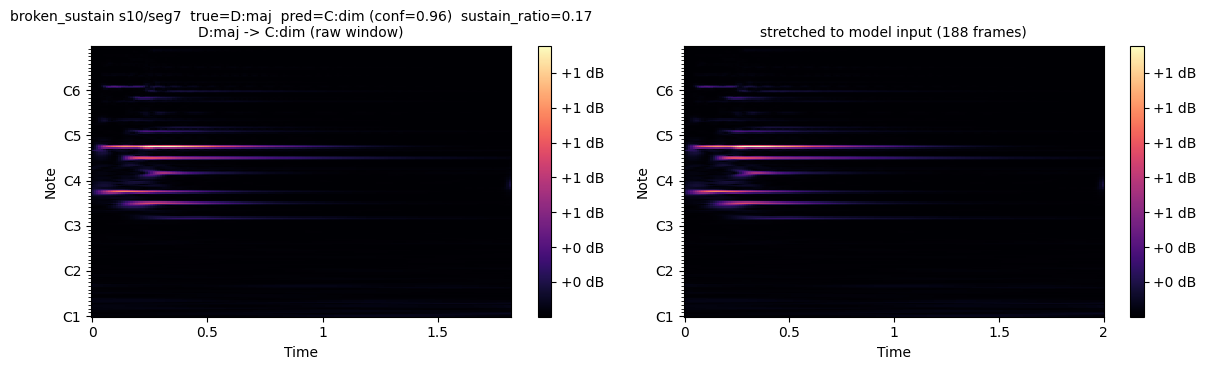

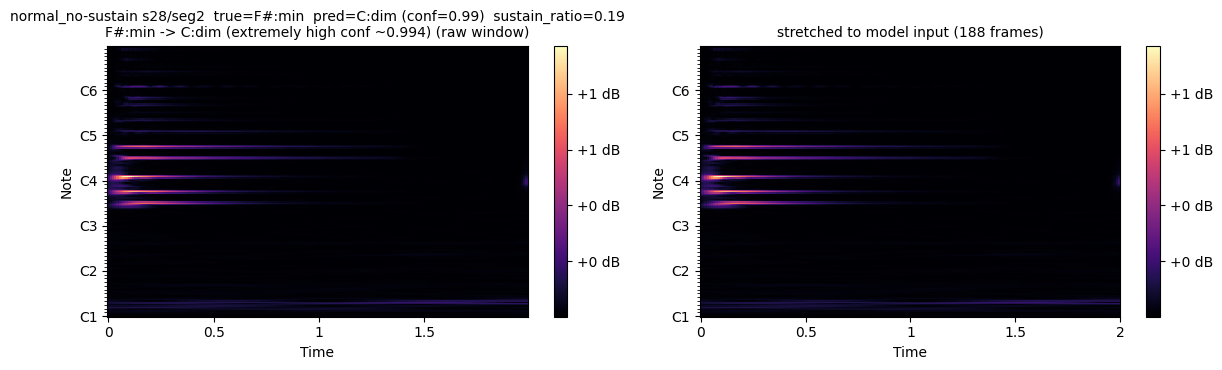

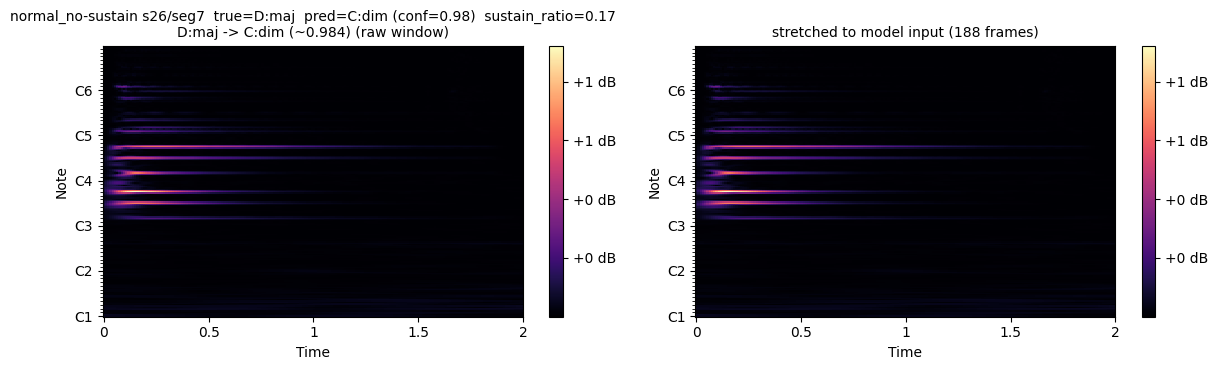

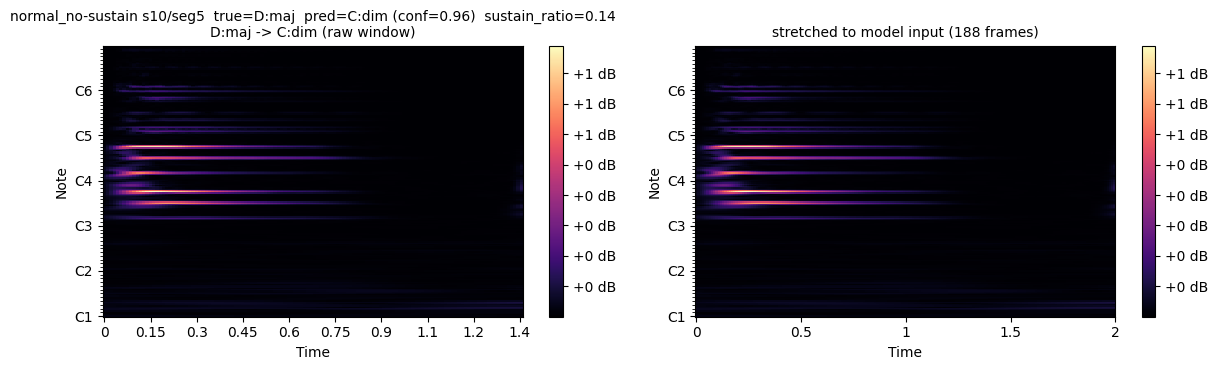

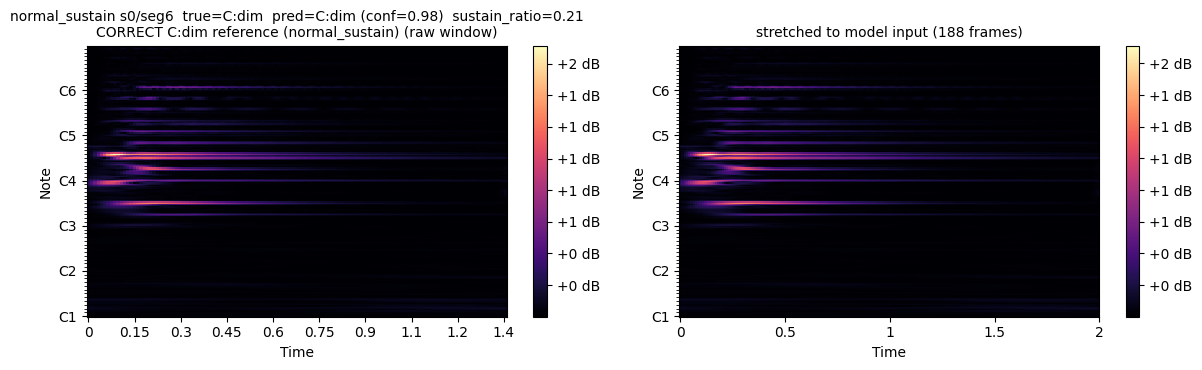

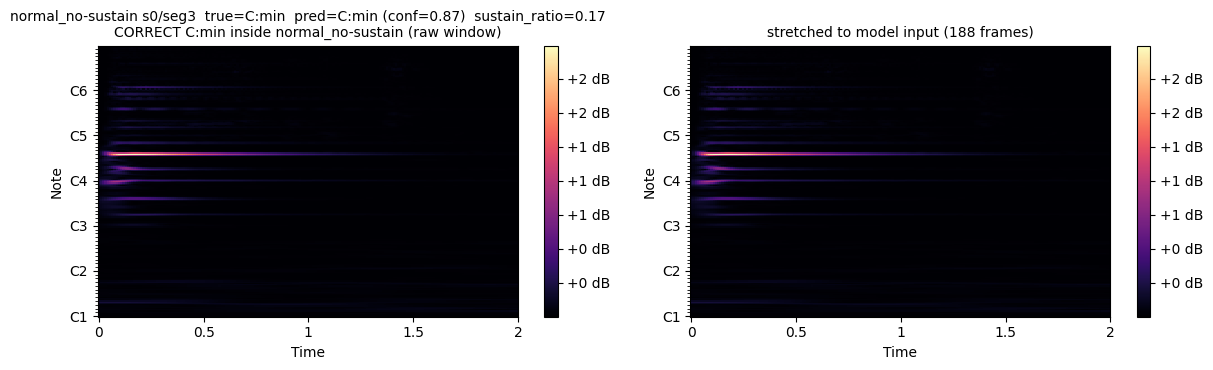

In [8]:
print("Generating case study CQT plots (raw + stretched views)...")
for case in CASES:
    try:
        plot_case_study(case, raw_data)
    except Exception as e:
        print(f"Failed on case {case}: {e}")


# Observations & next steps (fill in after looking at the plots)

Typical things you will likely see in the CQT plots for the high-confidence `... -> C:dim` errors:

- In `normal_no-sustain` the raw windows are often very "front-loaded": strong vertical striations (the attack / bow noise / hammer) in the first 20-40 frames, then rapid drop to near noise floor. After stretching to 188 frames the harmonic structure looks "smeared" or diluted over a long low-energy region.
- The reference correct `C:dim` (and other correct chords) from `normal_sustain` show much more stable, continuous horizontal energy bands (sustained partials) across most of the window.
- Many of the misclassified majors/minors still have clear root-fifth structure, but because the sustain tail is missing the CNN appears to latch onto a "diminished-like" sparse or flattened template that it learned for C:dim (perhaps because some training C:dim examples also had particular voicings or lower energy).

**Quantitative support** already visible in the sustain_ratio stats and the conditional error rates:
- `normal_no-sustain` has the lowest average sustain_ratio.
- Segments with sustain_ratio << 1 have substantially higher error rates in the bad datasets.

**Possible root causes** (not mutually exclusive):
1. **Domain shift in temporal envelope** — the training data (features/opus-*.npz etc.) was built from sustained/chordal material; the CNN + stretch preprocessing expects relatively stable energy across ~2 s.
2. **Source sample selection bias** — the "normal" / "delay" source chords used to build the three validation sets may have different recording chains, mics, or playing techniques for the "no-sustain" and "broken" buckets.
3. **C:dim as a 'garbage' class** — C:dim may be the model's nearest neighbor in embedding space for "unclear / low-sustain / inharmonic" inputs (its interval content is ambiguous and it is relatively rare, so the decision boundary may be loose).

**Ideas for further analysis in this notebook or follow-ups**:
- t-SNE / UMAP on the flattened (stretched) CQT patches for error vs correct populations, colored by dataset.
- Compare against a chroma or CENS representation of the same windows (does the bias disappear?).
- Retrain or fine-tune with heavy augmentation on short/decaying versions of the training chords.
- Look at the actual model weights / activation maps for the C:dim output unit on a failing example vs a good one (using tf-keras-vis or similar).
- Export a small "failure set" of the worst (high-conf, low-sustain) misclassified windows + their original audio snippets for listening.

Save the dataframes for offline slicing:


In [9]:
# Save the analysis tables for further work outside the notebook
out_dir = path.normpath(".")
segments_path = path.join(out_dir, "classification_segments_analysis.csv")
errors_path = path.join(out_dir, "classification_errors_analysis.csv")
segments_df.to_csv(segments_path, index=False)
errors_df.to_csv(errors_path, index=False)
print("Saved:")
print(" ", segments_path)
print(" ", errors_path)
print("\nYou can now do ad-hoc pandas slicing, e.g.:")
print("  errors_df.query(\"dataset==\\\"normal_no-sustain\\\" and pred==\\\"C:dim\\\" and confidence > 0.9\")")

print("\nNotebook run complete. Re-execute the case study cell after any changes to CASES.")
gc.collect()


Saved:
  ./classification_segments_analysis.csv
  ./classification_errors_analysis.csv

You can now do ad-hoc pandas slicing, e.g.:
  errors_df.query("dataset==\"normal_no-sustain\" and pred==\"C:dim\" and confidence > 0.9")

Notebook run complete. Re-execute the case study cell after any changes to CASES.


37757

In [10]:
display(segments_df.groupby(["dataset", "correct"]).spectral_std.agg(["mean", "median"]).round(3))
display(segments_df.groupby(["dataset", "correct"]).spectral_flatness.agg(["mean", "median"]).round(3))

mean  median
dataset           correct                
broken_sustain    False    12.036  12.396
                  True     12.943  12.371
normal_no-sustain False     7.658   7.445
                  True      9.390   9.230
normal_sustain    False    11.591  10.734
                  True     12.812  12.726

mean  median
dataset           correct               
broken_sustain    False    0.429   0.428
                  True     0.425   0.429
normal_no-sustain False    0.442   0.443
                  True     0.412   0.409
normal_sustain    False    0.448   0.457
                  True     0.399   0.397